In [ ]:
# Lightweight path setup for local Jupyter, VS Code, or Colab runs.
# It keeps the notebook runnable whether you start it from this folder or the repo root.
from pathlib import Path
import os

FOLDER_NAME = '01-Regression-Analysis'
NOTEBOOK_NAME = 'Project01_SimpleRegression.ipynb'

candidates = [
    Path.cwd(),
    Path.cwd() / FOLDER_NAME,
    Path.cwd() / "10-deep_learning" / FOLDER_NAME,
    Path.cwd().parent / FOLDER_NAME,
    Path.cwd().parent / "10-deep_learning" / FOLDER_NAME,
]

for candidate in candidates:
    if (candidate / NOTEBOOK_NAME).exists():
        os.chdir(candidate)
        break

print("Working directory:", Path.cwd().resolve())


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')

# Importing data

In [4]:
df = pd.read_csv('Regression_Data.csv')

In [5]:
df

,Ind_Data,Dependent_Data
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


# Create arrays for features and target variable

In [6]:
X = df['Ind_Data'].values
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [7]:
y = df['Dependent_Data'].values
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

# Visualizing the Scatter plot between X and y

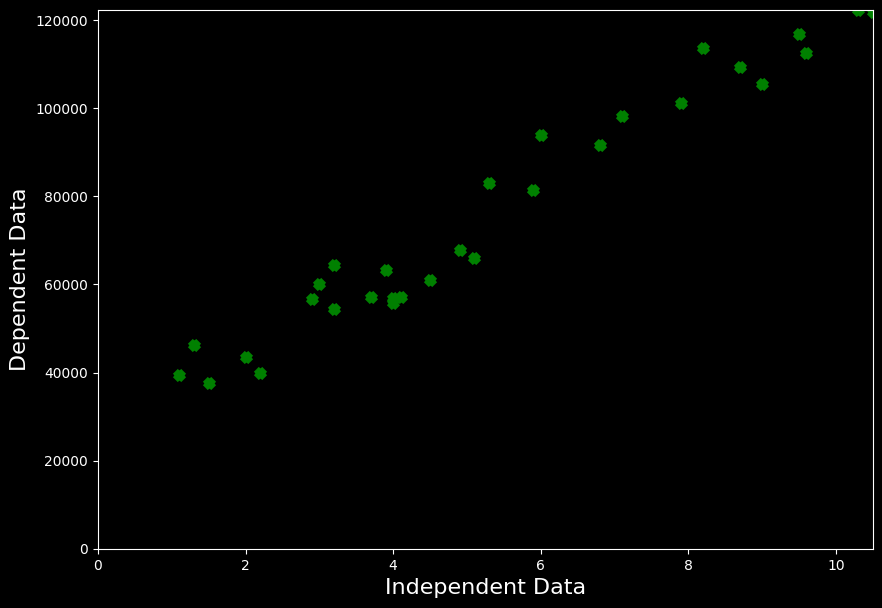

In [8]:
plt.figure(figsize=(10,7))
plt.scatter(X, y, marker = "x", color = 'g', lw = 5)
plt.xlabel('Independent Data', fontsize = 16)
plt.ylabel('Dependent Data', fontsize = 16)
plt.xlim([0, X.max()])
plt.ylim([0, y.max()])
plt.show()

# Applying Least Square

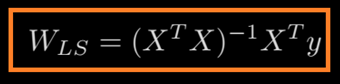

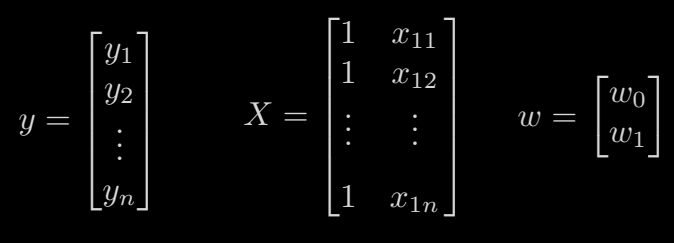

# Appending ones at the first column of X

In [9]:
ones = np.ones((len(X),1))
ones

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [10]:
X = X.reshape(-1,1)
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [11]:
Xls = np.concatenate((ones,X),axis=1)

In [12]:
Xls

array([[ 1. ,  1.1],
       [ 1. ,  1.3],
       [ 1. ,  1.5],
       [ 1. ,  2. ],
       [ 1. ,  2.2],
       [ 1. ,  2.9],
       [ 1. ,  3. ],
       [ 1. ,  3.2],
       [ 1. ,  3.2],
       [ 1. ,  3.7],
       [ 1. ,  3.9],
       [ 1. ,  4. ],
       [ 1. ,  4. ],
       [ 1. ,  4.1],
       [ 1. ,  4.5],
       [ 1. ,  4.9],
       [ 1. ,  5.1],
       [ 1. ,  5.3],
       [ 1. ,  5.9],
       [ 1. ,  6. ],
       [ 1. ,  6.8],
       [ 1. ,  7.1],
       [ 1. ,  7.9],
       [ 1. ,  8.2],
       [ 1. ,  8.7],
       [ 1. ,  9. ],
       [ 1. ,  9.5],
       [ 1. ,  9.6],
       [ 1. , 10.3],
       [ 1. , 10.5]])

In [13]:
y = y.reshape(-1,1)
y

array([[ 39343],
       [ 46205],
       [ 37731],
       [ 43525],
       [ 39891],
       [ 56642],
       [ 60150],
       [ 54445],
       [ 64445],
       [ 57189],
       [ 63218],
       [ 55794],
       [ 56957],
       [ 57081],
       [ 61111],
       [ 67938],
       [ 66029],
       [ 83088],
       [ 81363],
       [ 93940],
       [ 91738],
       [ 98273],
       [101302],
       [113812],
       [109431],
       [105582],
       [116969],
       [112635],
       [122391],
       [121872]])

# Applying Least Square Method

In [14]:
XT = np.transpose(Xls)   # Transpose of X

In [15]:
prod_X = np.matmul(XT,Xls)   # Calculating XT * X

In [16]:
Inv_X = np.linalg.inv(prod_X)             # calculating inverse of (XT * X)

In [17]:
XTy = np.matmul(XT,y)  # calculating (XT * y)

In [18]:
wLS = np.matmul(Inv_X,XTy)

In [19]:
wLS

array([[25792.20019867],
       [ 9449.96232146]])

In [20]:
w0 = wLS[0].round(2)
w0

array([25792.2])

In [21]:
w1 = wLS[1].round(2)
w1

array([9449.96])

# Interpreting the concept of weight

### w1 shows that the value of dependent variable increases by 9449.96 if the value of independent variable increases by one unit.

# Testing the model

In [22]:
test_data = np.linspace(0,11,30)

In [23]:
test_data

array([ 0.        ,  0.37931034,  0.75862069,  1.13793103,  1.51724138,
        1.89655172,  2.27586207,  2.65517241,  3.03448276,  3.4137931 ,
        3.79310345,  4.17241379,  4.55172414,  4.93103448,  5.31034483,
        5.68965517,  6.06896552,  6.44827586,  6.82758621,  7.20689655,
        7.5862069 ,  7.96551724,  8.34482759,  8.72413793,  9.10344828,
        9.48275862,  9.86206897, 10.24137931, 10.62068966, 11.        ])

In [24]:
test_labels = np.linspace(np.min(y), np.max(y), 30)

In [25]:
test_labels

array([ 37731.        ,  40650.31034483,  43569.62068966,  46488.93103448,
        49408.24137931,  52327.55172414,  55246.86206897,  58166.17241379,
        61085.48275862,  64004.79310345,  66924.10344828,  69843.4137931 ,
        72762.72413793,  75682.03448276,  78601.34482759,  81520.65517241,
        84439.96551724,  87359.27586207,  90278.5862069 ,  93197.89655172,
        96117.20689655,  99036.51724138, 101955.82758621, 104875.13793103,
       107794.44827586, 110713.75862069, 113633.06896552, 116552.37931034,
       119471.68965517, 122391.        ])

In [26]:
### Use the equation of regression to calculate predicted Values
y_pred = w0 + w1 * test_data  # y = w0 + w1X

# Visualizing the model performance

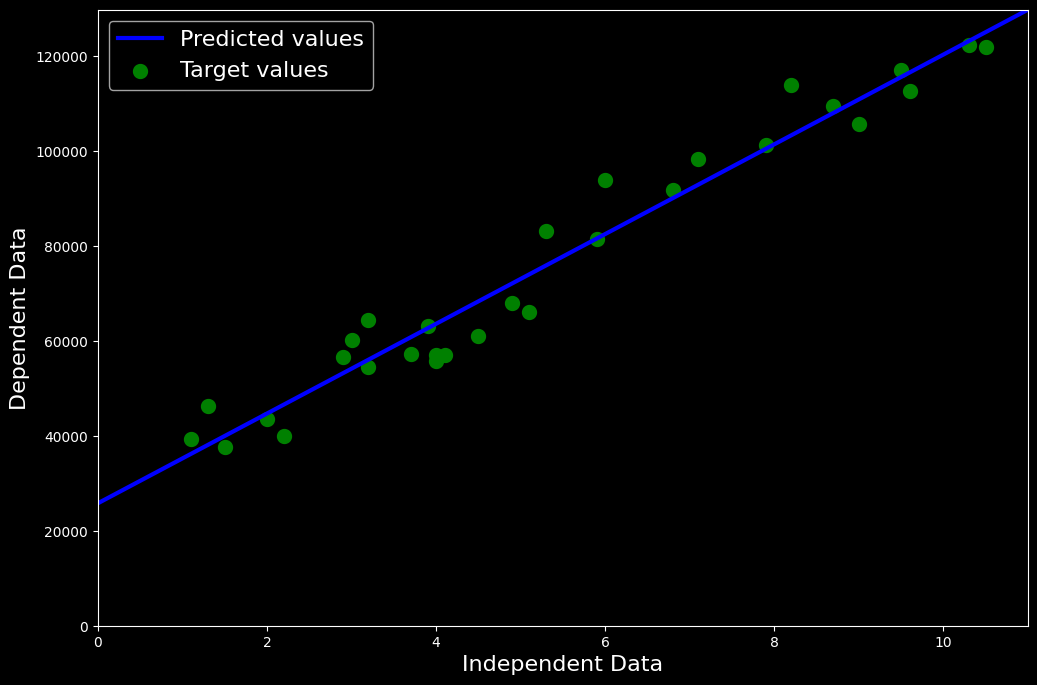

In [27]:
plt.figure(figsize=(12,8))
plt.xlim([0, test_data.max()])
plt.ylim([0, y_pred.max()])
plt.plot(test_data, y_pred, color='blue', label='Predicted values', linewidth = 3)
plt.scatter(X, y, c='green', label='Target values', linewidth = 5)
plt.xlabel('Independent Data', fontsize = 16)
plt.ylabel('Dependent Data', fontsize = 16)
plt.legend(fontsize = 16)
plt.show()


# Evaluating Regression Performance

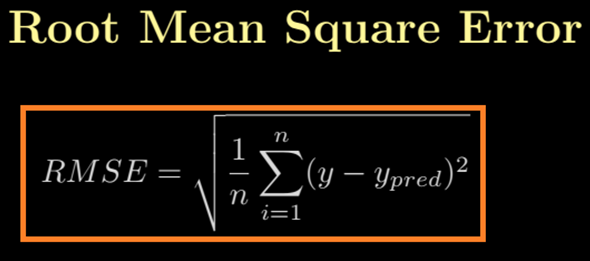

In [28]:
rmse = 0
for i in range(len(test_labels)):
    y_pred = w0 + w1 * test_data[i]
    rmse += (test_labels[i] - y_pred) ** 2
rmse = np.sqrt(rmse/len(test_labels))
print('RMSE : ',rmse)

RMSE :  [6197.43656114]


In [29]:
test_labels

array([ 37731.        ,  40650.31034483,  43569.62068966,  46488.93103448,
        49408.24137931,  52327.55172414,  55246.86206897,  58166.17241379,
        61085.48275862,  64004.79310345,  66924.10344828,  69843.4137931 ,
        72762.72413793,  75682.03448276,  78601.34482759,  81520.65517241,
        84439.96551724,  87359.27586207,  90278.5862069 ,  93197.89655172,
        96117.20689655,  99036.51724138, 101955.82758621, 104875.13793103,
       107794.44827586, 110713.75862069, 113633.06896552, 116552.37931034,
       119471.68965517, 122391.        ])

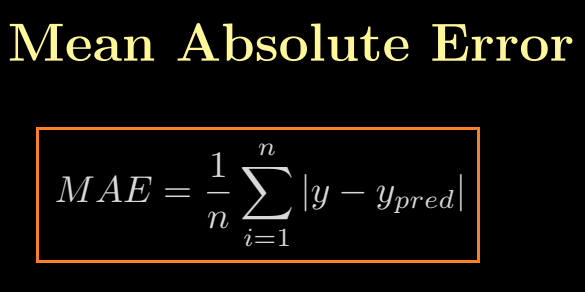

In [30]:
mae = 0
for i in range(len(test_labels)):
    y_pred = w0 + w1 * test_data[i]
    mae += abs(test_labels[i] - y_pred)
mae = mae / len(test_labels)
print('MAE :', mae)

MAE : [5247.93613793]


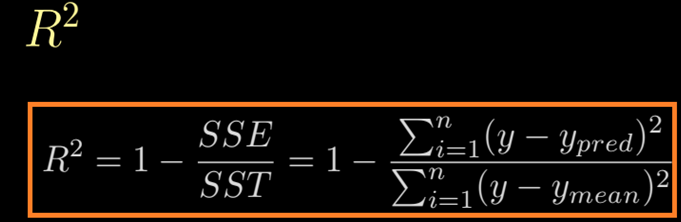

In [31]:
SSE = 0
SST = 0
for i in range(len(test_labels)):
    y_pred = w0 + w1 * test_data[i]
    SSE += (test_labels[i] - y_pred) ** 2
    SST += (test_labels[i] - np.mean(y)) ** 2
R2 = 1 - (SSE/SST)
print('R2 :',R2)


R2 : [0.94135569]


#  Using sklearn to perform Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()  # instantiate Linear Regression

In [33]:
lr.fit(X,y)  # Sk-Learn also does least square fitting
print("Intercept:", lr.intercept_)
print("Coefficient:", lr.coef_)

Intercept: [25792.20019867]
Coefficient: [[9449.96232146]]


In [34]:
test_data = test_data.reshape(-1,1)

In [35]:
y_pred = lr.predict(test_data)

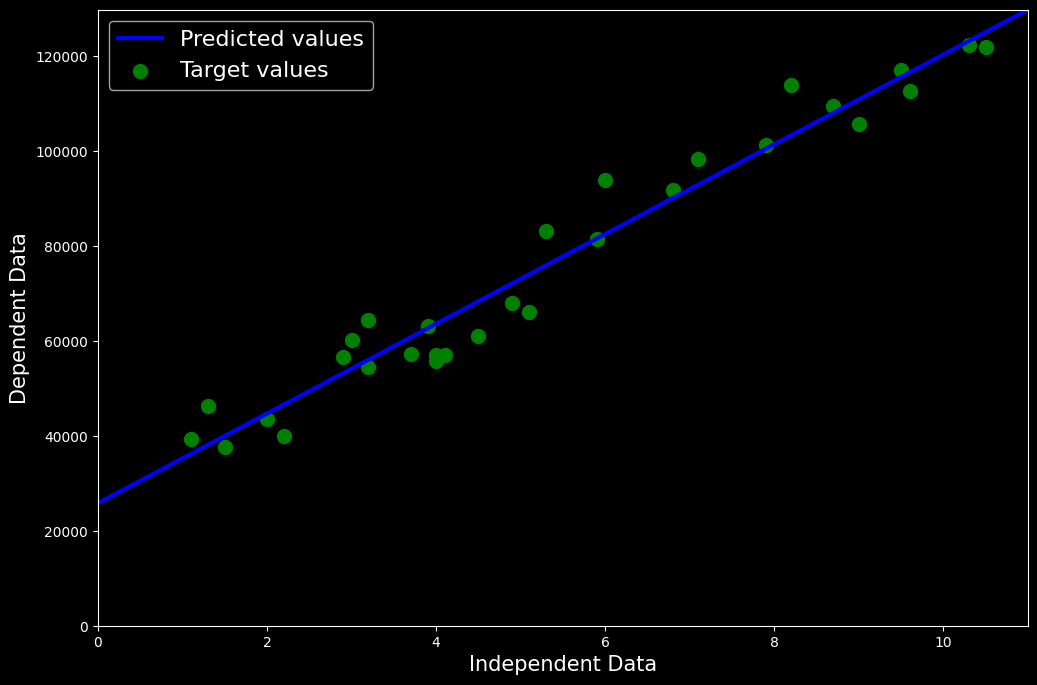

In [36]:
plt.figure(figsize=(12,8))
plt.xlim([0, test_data.max()])
plt.ylim([0, y_pred.max()])
plt.plot(test_data, y_pred, color='blue', label='Predicted values', linewidth = 3)
plt.scatter(X, y, c='green', label='Target values', linewidth = 5)
plt.xlabel('Independent Data', fontsize = 15)
plt.ylabel('Dependent Data', fontsize = 15)
plt.legend(fontsize = 16)
plt.show()


In [37]:
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))
print('MAE:', metrics.mean_absolute_error(test_labels, y_pred))
print('R2:', metrics.r2_score(test_labels, y_pred))


RMSE: 6197.438841666302
MAE: 5247.939884570575
R2: 0.9398430898737059
